<a href="https://colab.research.google.com/github/Mayar-alsulami/Final_Project/blob/main/Notebook_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/openpowerlifting_cleaned&features (1).csv')
df.head()

,Age,Sex,BodyweightKg,TotalKg,Equipment_Raw,Equipment_Single-ply,Equipment_Straps,Equipment_Wraps,Age_Weight_Ratio,Age_Bodyweight_Interaction,Is_Heavyweight,Using_Equipment,Heavyweight_Gear_Boost,Age_log,AgeGroup_Junior,AgeGroup_Adult,AgeGroup_Mature
0,47,0,59.60,138.35,0,0,0,1,0.788591,2801.20,0,1,0,2.127600,0,0,1
1,42,0,58.51,401.42,0,1,0,0,0.717826,2457.42,0,1,0,1.647680,0,0,1
2,42,0,58.51,95.25,1,0,0,0,0.717826,2457.42,0,0,0,1.647680,0,0,1
3,18,0,63.68,122.47,1,0,0,0,0.282663,1146.24,0,0,0,-1.915747,1,0,0
4,28,0,62.41,392.36,0,0,0,1,0.448646,1747.48,0,1,0,-0.070875,0,1,0


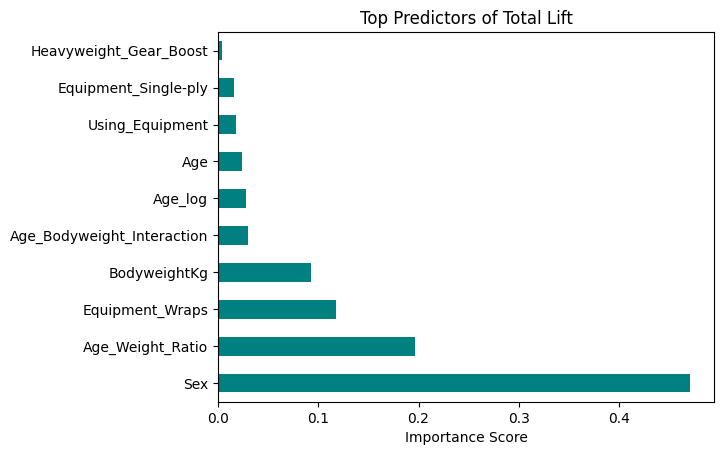

In [ ]:
import matplotlib.pyplot as plt

# 1. Prepare data (dropping redundant features as discussed)
X = df.drop(columns=['TotalKg', 'Equipment_Raw', 'AgeGroup_Mature'])
y = df['TotalKg']

# 2. Fit a quick Random Forest to see what REALLY matters
model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
model.fit(X, y)

# 3. Plot the importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top Predictors of Total Lift')
plt.xlabel('Importance Score')
plt.show()

To understand what truly drives powerlifting performance, a Random Forest Regressor was used to calculate "Feature Importance" scores. This reveals which variables the model relies on most when making a prediction.The Dominant Predictor: Sex is overwhelmingly the most important feature (Score $\approx 0.47$). This confirms that biological differences are the primary factor in absolute strength totals within this dataset.Engineered Success: The Age_Weight_Ratio is the second most important feature ($\approx 0.20$), outperforming raw bodyweight. This justifies our decision to engineer "relative" features rather than relying solely on raw numbers.Specific Gear Impact: Interestingly, Equipment_Wraps shows a higher importance than the general Using_Equipment flag. This suggests the model finds the specific mechanical advantage of knee wraps to be a more precise signal for high-total lifters.Interaction Maturity: While raw BodyweightKg remains significant, our engineered Age_Bodyweight_Interaction and Age_log terms provide the nuanced modifiers the model needs to adjust its baseline for different career stages.